Also defining redshift failure as ZWARN!=0. For comparing with COSMOS low-z observations.

In [1]:
from __future__ import division, print_function
import sys, os, glob, time, warnings, gc
import numpy as np
# import matplotlib
# matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from astropy.table import Table, vstack, hstack, join
import fitsio
# from astropy.io import fits

from scipy.optimize import curve_fit, minimize

In [2]:
params = {'legend.fontsize': 'x-large',
          'axes.labelsize': 'x-large',
          'axes.titlesize': 'x-large',
          'xtick.labelsize': 'x-large',
          'ytick.labelsize': 'x-large',
          'figure.facecolor': 'w',
          'xtick.top': True,
          'ytick.right': True,
          'xtick.direction': 'in',
          'ytick.direction': 'in',
         }
plt.rcParams.update(params)

In [3]:
# perexp = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_perexp_lrg.fits'))
perexp = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_perexp_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = perexp['FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove "no data" fibers
mask = perexp['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Apply LRG mask
mask = perexp['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove QSO targets
mask = perexp['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove objects classified as QSOs
mask = perexp['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

# Remove objects classified as STARs
mask = perexp['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
perexp = perexp[mask]

perexp['main_survey'] = False

FIBERSTATUS 464751 107007 0.18715435551404616
No data 464751 0 0.0
LRG mask 417693 47058 0.10125422000167832
Remove QSO targets 403772 13921 0.03332830571735701
Remove objects classified as QSOs: 398156 5616 0.013908839642174296
Remove objects classified as STARs: 395487 2669 0.006703402686384231


In [4]:
# cat_1x = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_1x_depth_lrg.fits'))
cat_1x = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_1x_depth_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = cat_1x['COADD_FIBERSTATUS']==0
print('FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove "no data" fibers
mask = cat_1x['ZWARN'] & 2**9==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Apply LRG mask
mask = cat_1x['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove QSO targets
mask = cat_1x['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove objects classified as QSOs
mask = cat_1x['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

# Remove objects classified as STARs
mask = cat_1x['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat_1x = cat_1x[mask]

cat_1x['main_survey'] = False

FIBERSTATUS 27110 4943 0.15421333416528873
No data 27110 0 0.0
LRG mask 25008 2102 0.07753596458871265
Remove QSO targets 24493 515 0.020593410108765194
Remove objects classified as QSOs: 24169 324 0.013228269301433063
Remove objects classified as STARs: 24013 156 0.0064545492159377715


In [5]:
# deep = Table(fitsio.read('/global/cfs/cdirs/desi/users/rongpu/spectro/fugu/sv1_cumulative_lrg.fits'))
deep = Table(fitsio.read('/Users/rongpu/Documents/Data/desi_data/fugu/sv1_cumulative_lrg.fits'))

# Remove FIBERSTATUS!=0 fibers
mask = deep['COADD_FIBERSTATUS']==0
print('COADD_FIBERSTATUS',np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

mask = deep['ZWARN']==0
print('No data', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Apply LRG mask
mask = deep['lrg_mask']==0
print('LRG mask', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove QSO targets
mask = deep['SV1_DESI_TARGET'] & 2**2 ==0
print('Remove QSO targets', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove objects classified as QSOs
mask = deep['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

# Remove objects classified as STARs
mask = deep['SPECTYPE']!='STAR'
print('Remove objects classified as STARs:', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
deep = deep[mask]

deep['main_survey'] = False

COADD_FIBERSTATUS 46319 8916 0.16141938987960533
No data 45437 882 0.01904186187093849
LRG mask 41340 4097 0.09016880515879129
Remove QSO targets 39668 1672 0.040445089501693274
Remove objects classified as QSOs: 39299 369 0.009302208329131794
Remove objects classified as STARs: 38993 306 0.007786457670678643


In [6]:
cat = vstack([perexp, cat_1x, deep], join_type='inner')
print(len(cat))

cat['EFFTIME_ELG'] = 8.60 * cat['TSNR2_ELG']
cat['EFFTIME_LRG'] = 12.15 * cat['TSNR2_LRG']
cat['zfibermag'] = 22.5 - 2.5*np.log10(cat['FIBERFLUX_Z']) - 1.211 * cat['EBV']
cat['FIBERFLUX_Z_EC'] = cat['FIBERFLUX_Z']*10**(0.4*1.211*cat['EBV'])

458493


In [7]:
cat['q0'] = cat['ZWARN']==0
cat['qf'] = np.array(cat['q0'], dtype=float)

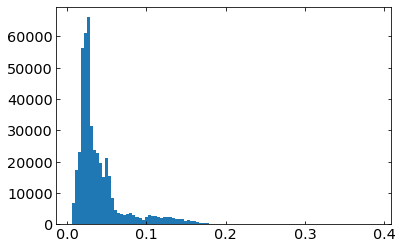

In [8]:
plt.hist(cat['EBV'], 100);

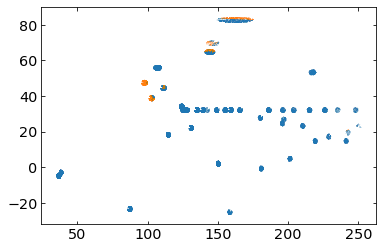

In [9]:
mask = cat['EBV']<0.1
plt.plot(cat['TARGET_RA'][mask], cat['TARGET_DEC'][mask], '.', ms=0.1, alpha=0.1)
plt.plot(cat['TARGET_RA'][~mask], cat['TARGET_DEC'][~mask], '.', ms=0.1, alpha=0.1)
plt.show()

In [10]:
mask = cat['EBV']<0.1
print(np.sum(mask)/len(mask))
cat = cat[mask]

0.9160008985960527


In [11]:
# Remove objects classified as QSOs
mask = cat['SPECTYPE']!='QSO'
print('Remove objects classified as QSOs', np.sum(mask), np.sum(~mask), np.sum(~mask)/len(mask))
cat = cat[mask]

Remove objects classified as QSOs 419980 0 0.0


In [29]:
mask = cat['EFFTIME_LRG']>700
mask &= cat['EFFTIME_LRG']<3000
cat = cat[mask]
print(len(cat))

mask = cat['zfibermag']>19.
mask &= cat['zfibermag']<22.
cat = cat[mask]
print(len(cat))

98247
98247


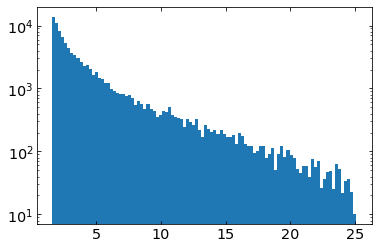

In [30]:
plt.hist(cat['FIBERFLUX_Z_EC'], 100, log=True);

In [31]:
print(np.sum((~cat['q0'])), np.sum((~cat['q0']))/len((~cat['q0'])))
mask = (cat['EFFTIME_LRG']>800) & (cat['EFFTIME_LRG']<1200)
print(np.sum((~cat['q0']) & mask), np.sum((~cat['q0']) & mask)/np.sum(mask))

3900 0.03969586857613973
2273 0.03924988344183316


-------

95.102745


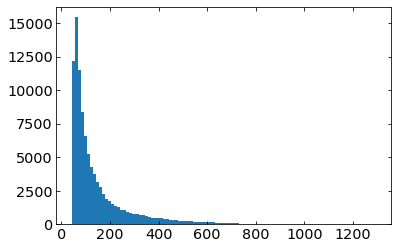

In [32]:
sn = cat['FIBERFLUX_Z_EC']*np.sqrt(cat['EFFTIME_LRG'])
print(np.median(sn))
plt.hist(sn, 100);

In [33]:
def cost(q_predict):
    return np.sum((cat['qf']-q_predict)**2)

def wrapper(coeffs):
    q_predict = 1-failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)
    return cost(q_predict)

# def failure_rate(flux, efftime, a, b):
#     sn = flux * np.sqrt(efftime)
#     return np.clip(np.exp(-(sn+a)/b), 0, 1)
# res = minimize(wrapper, [0, 10.], bounds=((-200, 200), (0, 100)),
#                method='Powell', tol=1e-6)

# Add 1/flux term
def failure_rate(flux, efftime, a0, a1, a2):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(a0*sn+a1)+a2/flux, 0, 1)

res = minimize(wrapper, [-0.09, 3., 0.02], bounds=((-1., 0.), (0, 100), (0., 1)),
               method='Powell', tol=1e-9)

# # Include minimal failure rate
# def failure_rate(flux, efftime, a, b, c):
#     sn = flux * np.sqrt(efftime)
#     return np.clip(np.exp(-(sn+a)/b)-c, 0, 1)
# res = minimize(wrapper, [0, 10., 0.001], bounds=((-200, 200), (0, 100), (0, 0.01)),
#                method='Powell', tol=1e-6)

# # Include sky contribution
# def failure_rate(flux, efftime, a, b, c):
#     sn = flux / np.sqrt(flux + c) * np.sqrt(efftime)
#     return np.clip(np.exp(-(sn+a)/b), 0, 1)
# res = minimize(wrapper, [-1.16346025e-01, 2.3,  10],
#                method='Powell', tol=1e-6)

print(res)
coeffs = res.x
print()
print(coeffs)
print(wrapper(coeffs))

   direc: array([[ 2.27764466e-04,  6.65567818e-05,  9.50399955e-05],
       [ 6.22327494e-05,  1.57243263e-03, -1.12060325e-03],
       [ 8.80320245e-03, -4.17517583e-01, -6.64147692e-03]])
     fun: 3338.4341544089043
 message: 'Optimization terminated successfully.'
    nfev: 1151
     nit: 9
  status: 0
 success: True
       x: array([-0.08598046,  2.5579393 ,  0.00317083])

[-0.08598046  2.5579393   0.00317083]
3338.4341544089043


In [36]:
# coeffs = [-0.09020459, 2.79460563, 0.00422004]
coeffs = [-0.08598046,  2.5579393 ,  0.00317083]

In [37]:
def failure_rate_sn_term(flux, efftime, a0, a1, a2):
    sn = flux * np.sqrt(efftime)
    return np.clip(np.exp(a0*sn+a1), 0, 1)

def failure_rate_flux_term(flux, efftime, a0, a1, a2):
    return np.clip(a2/flux, 0, 1)

In [38]:
fail_prob = failure_rate(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)
fail_prob_sn_term = failure_rate_sn_term(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)
fail_prob_flux_term = failure_rate_flux_term(cat['FIBERFLUX_Z_EC'], cat['EFFTIME_LRG'], *coeffs)

cat['success_prob'] = 1-fail_prob
print(np.sum(~cat['q0']), np.sum(1-cat['success_prob']))
print(np.sum(~cat['q0'])/np.sum(1-cat['success_prob']))

3900 3890.1616
1.0025290411721979


In [39]:
print(np.sum(fail_prob), np.sum(fail_prob_sn_term)+np.sum(fail_prob_flux_term), np.sum(fail_prob_sn_term), np.sum(fail_prob_flux_term))

mask = np.full(len(cat), True)
print(np.sum(fail_prob[mask]), np.sum(fail_prob_sn_term[mask])+np.sum(fail_prob_flux_term[mask]),
      np.sum(fail_prob_sn_term[mask]), np.sum(fail_prob_flux_term[mask]))

3890.1616 3890.1616 3785.5186 104.64314
3890.1616 3890.1616 3785.5186 104.64314


Failure rate at zfiber=21.6:
0.026840356748426226


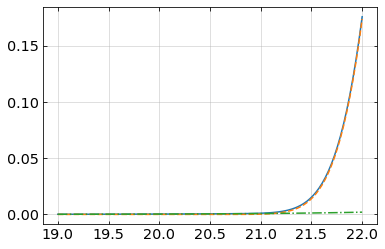

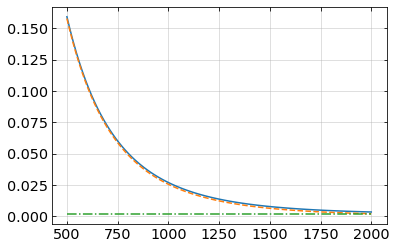

In [40]:
zfiber = 21.6
flux = 10**(-0.4*(zfiber-22.5))
efftime = 1000.
print('Failure rate at zfiber=21.6:')
print(failure_rate(flux, efftime, *coeffs))

zfiber = np.linspace(19, 22, 100)
flux = 10**(-0.4*(zfiber-22.5))
efftime = np.full(len(zfiber), 1000.)
plt.plot(zfiber, failure_rate(flux, efftime, *coeffs))
plt.plot(zfiber, failure_rate_sn_term(flux, efftime, *coeffs), '--')
plt.plot(zfiber, failure_rate_flux_term(flux, efftime, *coeffs), '-.')
plt.grid(alpha=0.5)
plt.show()

efftime = np.linspace(500, 2000, 100)
zfiber = np.full(len(efftime), 21.6)
flux = 10**(-0.4*(zfiber-22.5))
plt.plot(efftime, failure_rate(flux, efftime, *coeffs))
plt.plot(efftime, failure_rate_sn_term(flux, efftime, *coeffs), '--')
plt.plot(efftime, failure_rate_flux_term(flux, efftime, *coeffs), '-.')
plt.grid(alpha=0.5)
plt.show()

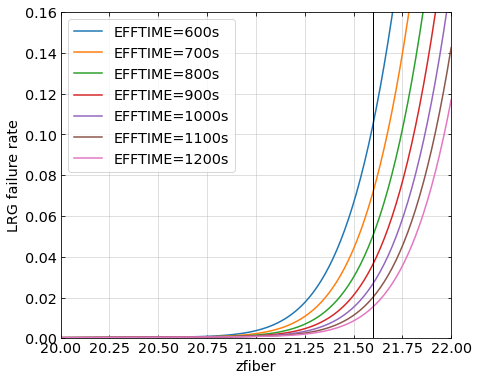

In [41]:
zfiber = 21.6
flux = 10**(-0.4*(zfiber-22.5))
efftimes = [600, 700, 800, 900, 1000., 1100, 1200]

zfiber = np.linspace(20., 22., 100)
flux = 10**(-0.4*(zfiber-22.5))
plt.figure(figsize=(7, 6))
for efftime in efftimes:
    efftime = np.full(len(zfiber), efftime)
    plt.plot(zfiber, failure_rate(flux, efftime, *coeffs), label='EFFTIME={:.0f}s'.format(efftime[0]))
plt.grid(alpha=0.5)
plt.ylabel('LRG failure rate')
plt.xlabel('zfiber')
plt.legend()
plt.axvline(21.6, lw=1, color='k')
plt.axis([20., 22., 0, 0.16])
plt.show()

<ipython-input-42-20e81ca29f43>:7: RuntimeWarning: invalid value encountered in true_divide
  success_2d = count_2d_good/count_2d_all


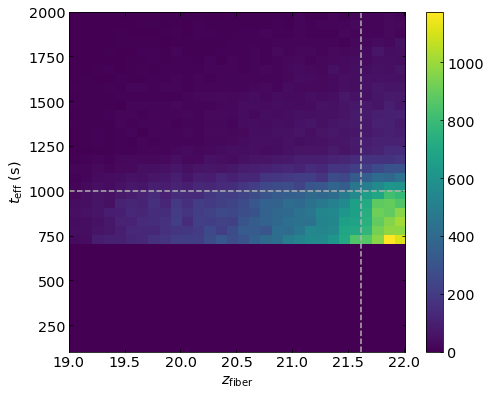

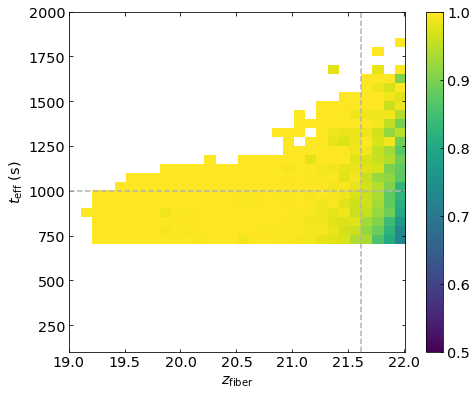

In [42]:
zfiber_bin_edges = np.linspace(18.01, 22.01, 41)
efftime_bin_edges = np.linspace(100, 2000, 39)

count_2d_all = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
mask = cat['q0'].copy()
count_2d_good = np.histogram2d(cat['zfibermag'][mask], cat['EFFTIME_LRG'][mask], bins=[zfiber_bin_edges, efftime_bin_edges])[0]
success_2d = count_2d_good/count_2d_all

success_2d[count_2d_all<=50] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(count_2d_all.T, origin='lower', aspect='auto',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

<ipython-input-43-119191d5c7ca>:2: RuntimeWarning: invalid value encountered in true_divide
  success_2d_predict = count_2d_good_predict/count_2d_all


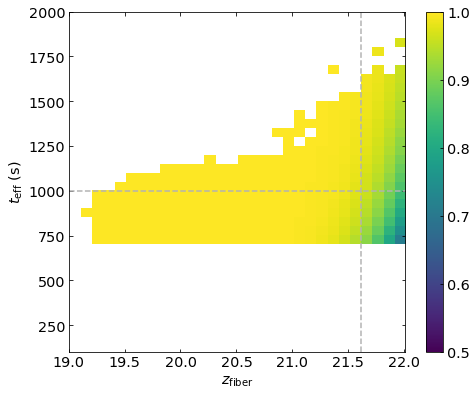

In [43]:
count_2d_good_predict = np.histogram2d(cat['zfibermag'], cat['EFFTIME_LRG'], bins=[zfiber_bin_edges, efftime_bin_edges], weights=cat['success_prob'])[0]
success_2d_predict = count_2d_good_predict/count_2d_all

success_2d_predict[count_2d_all<=50] = np.nan

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow(success_2d_predict.T, origin='lower', aspect='auto', vmin=0.5, vmax=1.,
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

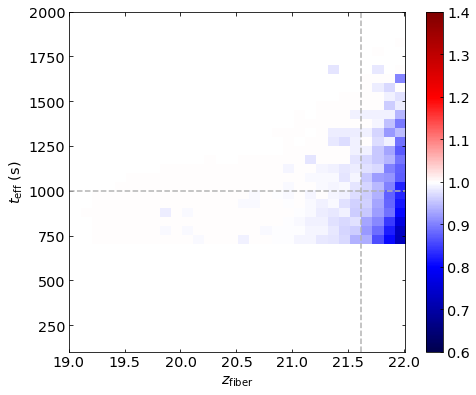

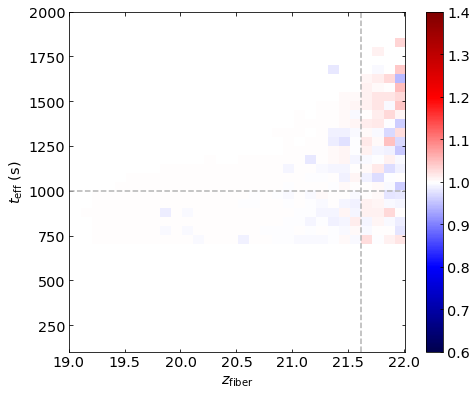

In [44]:
fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow((success_2d).T, origin='lower', aspect='auto', vmin=0.6, vmax=1.4, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 5.6))
cax = ax.imshow((success_2d/success_2d_predict).T, origin='lower', aspect='auto', vmin=0.6, vmax=1.4, cmap='seismic',
           extent=(zfiber_bin_edges.min(), zfiber_bin_edges.max(), efftime_bin_edges.min(), efftime_bin_edges.max()))
ax.set_xlabel('$z_\mathrm{fiber}$')
ax.set_ylabel('$t_\mathrm{eff}$ (s)')
ax.set_xlim(xmin=19)
ax.axhline(1000., color='0.7', ls='--')
ax.axvline(21.61, color='0.7', ls='--')
plt.colorbar(cax)
plt.tight_layout()
plt.show()

------

In [45]:
def binned_frac(x, y, bin_edges, minsize=10, error_floor=True):
    bin_center = (bin_edges[1:] + bin_edges[:-1])/2
    bin_frac = np.zeros(len(bin_edges)-1)
    bin_frac_err = np.zeros(len(bin_edges)-1)
    for index in range(len(bin_edges)-1):
        mask = (x>bin_edges[index]) & (x<=bin_edges[index+1])
        if np.sum(mask)<minsize:
            bin_frac[index] = np.nan
            bin_frac_err[index] = np.nan
        else:
            n, p = np.sum(mask), np.mean(y[mask])
            if error_floor:
                p1 = np.maximum(p, 1/n)  # error floor
            else:
                p1 = p
            bin_frac[index] = p
            bin_frac_err[index] = np.clip(np.sqrt(n * p * (1-p))/n, np.sqrt(n * p1 * (1-p1))/n, 1)
    
    return bin_center, bin_frac, bin_frac_err

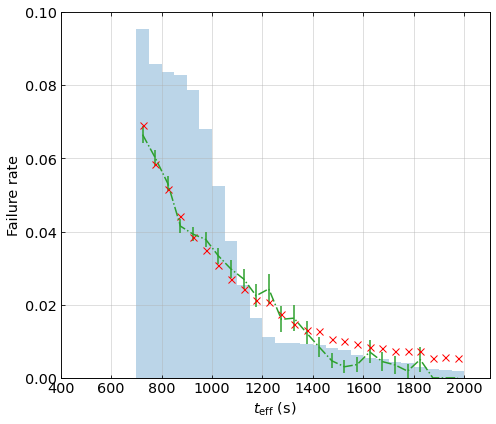

In [46]:
mask = np.full(len(cat), True)
# mask &= (cat['main_lrg'].copy())

area = len(cat)/600

bin_edges = np.linspace(0, 2000, 41)
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['EFFTIME_LRG'][mask], (~cat['q0'][mask]), bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(cat['EFFTIME_LRG'][mask], 1-cat['success_prob'][mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7., 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', color='C2')
ax1.plot(bin_center, bin_reject_rate_predict, 'x', color='r', ms=7)
# ax1.xlabel('EFFTIME_LRG')
ax1.set_xlabel('$t_\mathrm{eff}$ (s)')
ax1.set_ylabel('Failure rate')
ax1.grid(alpha=0.5)
# ax1.legend(loc='upper right')
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(cat['EFFTIME_LRG'][mask], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(np.sum(mask), 1/area))
# ax2.set_ylabel('a.u.', color=ax2_color)
# ax2.tick_params(axis='y', labelcolor=ax2_color)
ax2.yaxis.set_visible(False)
ax1.set_zorder(1)
ax1.patch.set_visible(False)
ax1.axis([400, 2100, 0.00, 0.1])
plt.tight_layout()
plt.show()

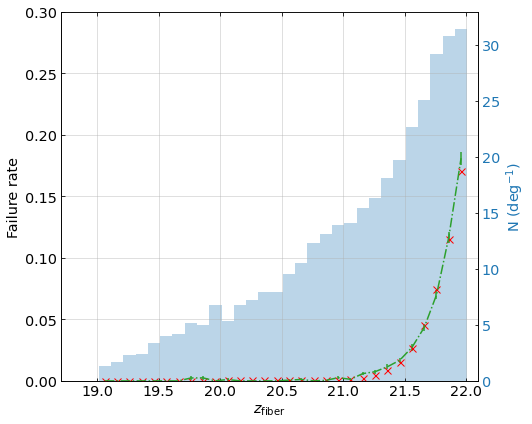

In [47]:
mask = (cat['EFFTIME_LRG']>800.) & (cat['EFFTIME_LRG']<1200.)
# mask &= cat['main_lrg'].copy()

bin_edges = np.linspace(18.01, 22.01, 41)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

# mask = mask & (cat['survey']=='main')
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(cat['zfibermag'][mask], (~cat['q0'])[mask], bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(cat['zfibermag'][mask], (1-cat['success_prob'])[mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7.5, 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', color='C2')
ax1.plot(bin_center, bin_reject_rate_predict, 'x', ms=7, color='r')
ax1.set_xlabel('$z_\mathrm{fiber}$')
ax1.set_ylabel('Failure rate')
ax1.grid(alpha=0.5)
# ax1.legend(loc='upper left')
# ax1.title('cat LRGs')
ax1.axis([18.7, 22.1, 0.00, 0.3])
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(cat['zfibermag'][mask], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(np.sum(mask), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
plt.show()

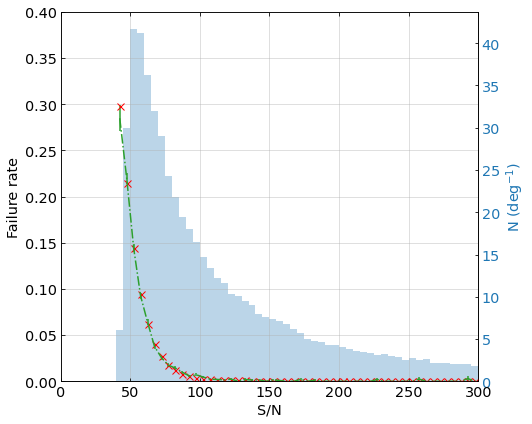

In [48]:
mask = (cat['EFFTIME_LRG']>200.)
# mask &= cat['main_lrg'].copy()

bin_edges = np.linspace(25, 325, 61)
bin_centers = (bin_edges[1:]+bin_edges[:-1])/2

# mask = mask & (cat['survey']=='main')
bin_center, bin_reject_rate, bin_reject_rate_err = binned_frac(sn[mask], (~cat['q0'])[mask], bin_edges, minsize=10, error_floor=False)
_, bin_reject_rate_predict, _ = binned_frac(sn[mask], (1-cat['success_prob'])[mask], bin_edges, minsize=10, error_floor=False)

fig, ax1 = plt.subplots(figsize=(7.5, 6.))
ax1.errorbar(bin_center, bin_reject_rate,
             yerr=(np.clip(bin_reject_rate_err, None, bin_reject_rate), bin_reject_rate_err),
             fmt='-.', color='C2')
ax1.plot(bin_center, bin_reject_rate_predict, 'x', ms=7, color='r')
ax1.set_xlabel('S/N')
ax1.set_ylabel('Failure rate')
ax1.grid(alpha=0.5)
# ax1.legend(loc='upper left')
# ax1.title('cat LRGs')
ax1.axis([0, 300, 0.00, 0.4])
ax2 = ax1.twinx()
ax2_color = 'C0'
ax2.hist(sn[mask], bins=bin_edges, color='C0', alpha=0.3, label=None, weights=np.full(np.sum(mask), 1/area))
ax2.set_ylabel('N (deg$^{-1}$)', color=ax2_color)
ax2.tick_params(axis='y', labelcolor=ax2_color)

ax1.set_zorder(1)
ax1.patch.set_visible(False)

plt.tight_layout()
plt.show()